In [84]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
from matplotlib.animation import FuncAnimation

## Creamos el caminante aleatorio

In [85]:

# Parametros
N = 150 # numero de pasos
nw = 1 # Numero de caminantes
dr = 0.2  # Distancia de paso radial

dist = np.zeros([nw,N], dtype= float)
angulo = np.zeros([nw,N], dtype= float)


for i in range(N):
    for k in range(nw):
        angle = np.deg2rad(rd.randint(0,359)) # Angulo aleatorio en radianes
        angulo[k,i] = angle
        dice = rd.random()
        if dice < 0.5:
            dist[k,i] = dist[k,i-1] + dr
        else:
            dist[k,i] = dist[k,i-1] - dr



## Creamos una figura

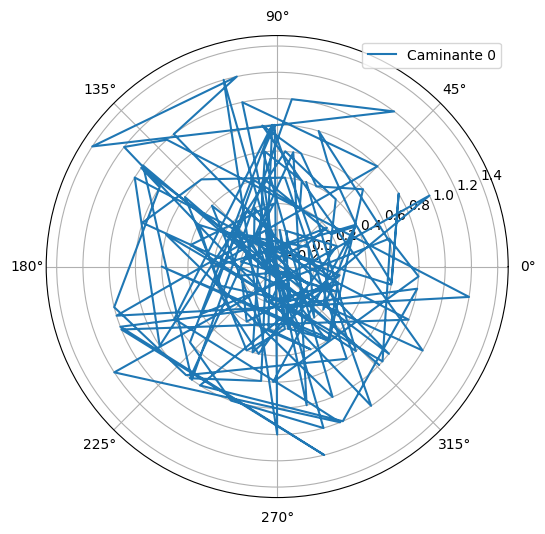

In [86]:
fig, ax =  plt.subplots(nrows=1, ncols=1, figsize = (6,6), subplot_kw= {'projection': 'polar'})


for j in range(nw):
    ax.plot(angulo[j,:], dist[j,:], label = f'Caminante {j}')


ax.legend()



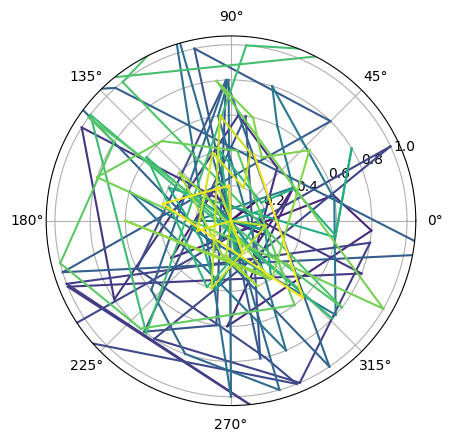

In [88]:
fig, ax = plt.subplots(subplot_kw={'projection':'polar'})

colores = plt.cm.viridis(np.linspace(0,1,N))

lineas = []
for i in range(nw):
    caminante = []
    for j in range(N-1):
        l, = ax.plot([],[], color=colores[j])
        caminante.append(l)
    lineas.append(caminante)



def update(frame):

    for w in range(nw):
        for j in range(frame):
            lineas[w][j].set_data(
                angulo[w,j:j+2],
                dist[w,j:j+2]
            )

    return sum(lineas,[])

anim = FuncAnimation(fig, func= update, frames= N, interval = 100, blit = True)

#plt.show()
anim.save('Random_polar.mp4', writer= 'ffmpeg')